In [1]:
print("all ok")

all ok


In [1]:
def hello_node(input:str):
    return {"message": f"Hello, {input}!"}

In [2]:
hello_node("sunny")

{'message': 'Hello, sunny!'}

In [3]:
hello_node("rajesh")

{'message': 'Hello, rajesh!'}

In [4]:
hello_node("langgraph")

{'message': 'Hello, langgraph!'}

In [5]:
from typing_extensions import TypedDict

In [7]:
class State(TypedDict):
    message: str

In [14]:
class State:
    message: str

In [15]:
State()

In [13]:
State({"message": "hello python"})

TypeError: 'dict' object is not callable

In [10]:
state: State = {"message": "hello python"}

In [11]:
State

{'message': 'hello python'}

In [16]:
def hello_node(state: State):
    return {"message": f"Hello, {state['message']}!"}

In [17]:
from langgraph.graph import StateGraph, START, END

In [27]:
builder = StateGraph(State)

In [28]:
builder.add_node("first_hello_node",hello_node)

In [29]:
builder.add_edge(START,"first_hello_node")

In [30]:
builder.add_edge("first_hello_node", END)

In [31]:
graph = builder.compile()

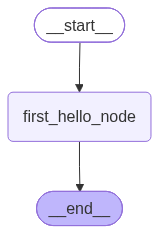

In [32]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [33]:
graph.invoke({"message": "from INDIA"})

{'message': 'Hello, from INDIA!'}

In [34]:
result = graph.invoke({"message": "from INDIA"})

In [35]:
result["message"]

'Hello, from INDIA!'

In [36]:
class Sunny(TypedDict):
    text: str
    

In [ ]:
state: Sunny = {"text": "hello"}

In [39]:
def function1(state: Sunny):
    print(f"state from first function : {state}")
    return {
        "text": state["text"] + " from first function"
    }

In [40]:
def function2(state: Sunny):
    print(f"state from second function : {state}")
    return {
        "text": state["text"] + " savita from second function"
    }

In [42]:
workflow = StateGraph(Sunny)

In [43]:
workflow.add_node("fun1", function1)
workflow.add_node("fun2", function2)

In [44]:
workflow.add_edge(START, "fun1")
workflow.add_edge("fun1", "fun2")
workflow.add_edge("fun2", END)

In [45]:
app = workflow.compile()

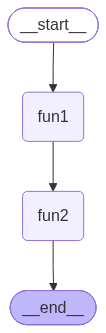

In [46]:
from IPython.display import Image, display

display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)

In [ ]:
#  return {
#         "text": state["text"] + " from first function"
#     }

In [48]:
result = app.invoke({"text": "hi this is sunny"})

state from first function : {'text': 'hi this is sunny'}
state from second function : {'text': 'hi this is sunny from first function'}


In [49]:
result

{'text': 'hi this is sunny from first function savita from second function'}

state from first function before return(this is input to the first function) : {'text': 'hi this is sunny'}
state from second function before return statement(this is output from the first function) : {'text': 'hi this is sunny from first function'}
final state after the section function output: {'text': 'hi this is sunny from first function savita from second function'}

In [50]:
result["text"]

'hi this is sunny from first function savita from second function'

In [51]:
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage

d:\complete_content_new\Full-Stack-GenAI-Bootcamp-1.0\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [52]:
from dotenv import load_dotenv
import os

load_dotenv()

True

In [53]:
if not os.getenv("GROQ_API_KEY"):
    raise ValueError(
        "GROQ_API_KEY not found. Please add it to your .env file."
    )


In [54]:
MODEL_NAME = "openai/gpt-oss-20b"
llm = ChatGroq(
    model=MODEL_NAME,
    temperature=0.6,
    reasoning_format="hidden"
)

In [55]:
response = llm.invoke("Hi")

print(response.content)

Hello! 👋 How can I help you today?


In [57]:
from langgraph.graph import MessagesState

In [ ]:
# class MessagesState(TypedDict):
#     messages: Annotated[list[AnyMessage], add_messages]

In [ ]:
# {"messages":["hi","how are are you?","what are you doing?"]}

In [58]:
def call_model(state: MessagesState):

    print("\n=========================")
    print("MYBOT NODE")
    print("=========================")

    # Get complete conversation history
    messages = state["messages"]

    print(
        "Current Messages:",
        messages
    )

    # Send complete message history to LLM
    response = llm.invoke(messages)

    print("\nModel Response:",response.content)

    # MessagesState internally uses add_messages reducer.
    # Therefore the new AIMessage will be added
    # to the existing list of messages.
    return {
        "messages": [response]
    }

In [59]:
workflow = StateGraph(MessagesState)

In [60]:
workflow.add_node("mybot",call_model)

In [61]:
workflow.add_edge(START,"mybot")
workflow.add_edge("mybot",END)

In [62]:
app = workflow.compile()

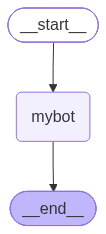

In [63]:
from IPython.display import (
    Image,
    display,
)


display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)

In [64]:
input = {"messages": [HumanMessage(content="Hi hello, how are you?")]}

In [65]:
result = app.invoke(input)


MYBOT NODE
Current Messages: [HumanMessage(content='Hi hello, how are you?', additional_kwargs={}, response_metadata={}, id='533176d6-bc09-4286-8bcb-0210a98e829a')]

Model Response: Hello! I’m doing great—thanks for asking. How about you? What’s on your mind today?


State Schema
│
├── TypedDict
│
│   class State(TypedDict):
│       text: str
│
├── Dataclass
│
│   @dataclass
│   class State:
│       text: str
│
├── Pydantic
│
│   class State(BaseModel):
│       text: str
│
└── Built-in MessagesState
    │
    └── messages + add_messages

## 4th workflow

In [82]:
response =llm.invoke("hi hello how are you?")

In [83]:
response.content

'Hello! 👋 I’m doing great—thanks for asking. How can I help you today?'

In [84]:
response.usage_metadata

{'input_tokens': 77,
 'output_tokens': 85,
 'total_tokens': 162,
 'output_token_details': {'reasoning': 56}}

In [69]:
from typing_extensions import TypedDict, NotRequired
from langchain_core.messages import AIMessage
class State(TypedDict):
    # User input
    question: str
    # Generated answer
    answer: NotRequired[str]
    # Complete model response
    response: NotRequired[AIMessage]
    # Token information
    input_tokens: NotRequired[int]
    output_tokens: NotRequired[int]
    total_tokens: NotRequired[int]

In [85]:
def llm_node(state: State):
    print("\n========================")
    print("LLM NODE")
    print("========================")
    
    response = llm.invoke(state["question"])
    print(
        "\nGenerated Answer:\n",
        response.content
    )
    
    # IMPORTANT:
    # We are NOT counting tokens here.
    # We simply save the complete AIMessage
    # so the next node can inspect its token metadata.
    return { "answer": response.content, "response": response}



In [86]:
def token_counter(state: State):
    print("\n========================")
    print("TOKEN COUNTER NODE")
    print("========================")
    response = state["response"]
    
    usage = response.usage_metadata or {}

    input_tokens = usage.get(
        "input_tokens"
    )

    output_tokens = usage.get(
        "output_tokens"
    )

    total_tokens = usage.get(
        "total_tokens"
    )

    print(
        "Input Tokens:",
        input_tokens
    )

    print(
        "Output Tokens:",
        output_tokens
    )

    print(
        "Total Tokens:",
        total_tokens
    )

    return {"input_tokens": input_tokens, "output_tokens": output_tokens, "total_tokens": total_tokens

    }

In [87]:
workflow = StateGraph(State)

In [88]:
workflow.add_node("llm", llm_node)

In [89]:
workflow.add_node("token_counter", token_counter)

In [90]:
workflow.add_edge(START, "llm")
workflow.add_edge("llm", "token_counter")
workflow.add_edge("token_counter", END)

In [91]:
app = workflow.compile()

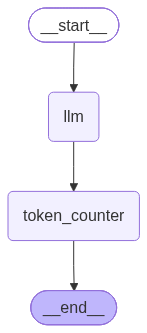

In [92]:
from IPython.display import Image, display

display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)

In [93]:
result = app.invoke({"question": "Tell me about Tata Group in detail."})


LLM NODE

Generated Answer:
 ## Tata Group – An In‑Depth Overview

The **Tata Group** is one of India’s oldest and most respected conglomerates, with a history that spans more than 150 years. Headquartered in Mumbai, the group operates in a broad spectrum of industries – from steel and automobiles to information technology, consumer goods, and financial services – and has a presence in over 100 countries worldwide.

Below is a comprehensive look at the group’s origins, structure, key businesses, governance, financials, global footprint, philanthropy, recent developments, and the challenges it faces.

---

### 1. Historical Background

| Year | Milestone |
|------|-----------|
| **1835** | *Tata Iron & Steel Works* founded by Jamsetji Tata in Nagpur, the first modern steel plant in India. |
| **1908** | *Tata Sons* is incorporated as a holding company to manage Tata’s expanding interests. |
| **1945** | Tata Group begins exporting, marking the start of its global expansion. |
| **1950s

In [94]:
result

{'question': 'Tell me about Tata Group in detail.',
 'answer': '## Tata Group – An In‑Depth Overview\n\nThe **Tata Group** is one of India’s oldest and most respected conglomerates, with a history that spans more than 150\u202fyears. Headquartered in Mumbai, the group operates in a broad spectrum of industries – from steel and automobiles to information technology, consumer goods, and financial services – and has a presence in over 100 countries worldwide.\n\nBelow is a comprehensive look at the group’s origins, structure, key businesses, governance, financials, global footprint, philanthropy, recent developments, and the challenges it faces.\n\n---\n\n### 1. Historical Background\n\n| Year | Milestone |\n|------|-----------|\n| **1835** | *Tata Iron & Steel Works* founded by Jamsetji Tata in Nagpur, the first modern steel plant in India. |\n| **1908** | *Tata Sons* is incorporated as a holding company to manage Tata’s expanding interests. |\n| **1945** | Tata Group begins exporting, m